In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/Churn_Modelling.csv")
df.head(5)
df.info()
df["Exited"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


Exited
0    7963
1    2037
Name: count, dtype: int64

In [60]:
df.groupby("Exited")["Age"].mean()  #yaş ortalamasına bakılır buna göre bir analiz yapılabilir


Exited
0    37.408389
1    44.837997
Name: Age, dtype: float64

In [61]:
df.groupby("Exited")["IsActiveMember"].mean()  #aktif üyelik oranına bakılır

Exited
0    0.554565
1    0.360825
Name: IsActiveMember, dtype: float64

In [62]:
df.groupby("Geography")["Exited"].mean()  #ülkelere göre churn oranına bakılır buna göre analiz yapılacak

Geography
France     0.161548
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64

In [63]:
df_model = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)
#kalıcı silmedim çünkü bir hata olursa geri dönebilirim bu şekilde


In [64]:
df_model.dtypes

CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [65]:
df_model["Gender"] = df_model["Gender"].map({
    "Male":1,
    "Female":0
}
)  #gender sütunu için encoding yaptım

df_model["Gender"].value_counts()

Gender
1    5457
0    4543
Name: count, dtype: int64

In [66]:
df_model = pd.get_dummies(
    df_model,
    columns=["Geography"],
    drop_first=True
)

#one hot encoding yaptım geography sütunu için

In [67]:
y = df_model["Exited"]
X = df_model.drop("Exited", axis=1)

#target feature ayrımı yaptım

X.shape, y.shape

((10000, 11), (10000,))

In [68]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y  #imbalanced data için stratify kullanılır
)


In [69]:
#Feature Scaling

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#scaling yani ölçekleme yaptım böylece sayısal featurelar aynı ölçeğe gelmiş oldu
#yani büyük sayılar ile küçük sayılar aynı seviyeye gelmiş oldu
#bu da modelin performansını artırır -> modelin büyük sayılara daha çok önem vermesini engeller

In [70]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

LogisticRegression()

In [71]:
y_pred = log_model.predict(X_test_scaled)
y_pred[0:10]  #y_pred bir numpy array olduğu için head kullanılmaz

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [72]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm   #confusion matrix oluşturdum

array([[1540,   53],
       [ 331,   76]])

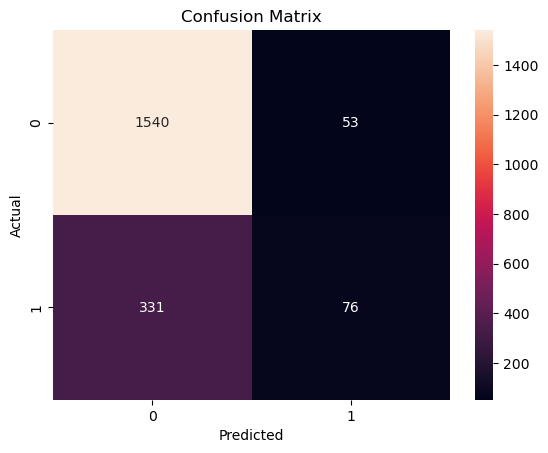

In [73]:
import seaborn as sns
sns.heatmap(cm, annot=True, fmt="d")  #annot ile hücre içine sayılar yazılır 
# fmt ile sayı formatı d-> integer f->float 
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()  

In [74]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



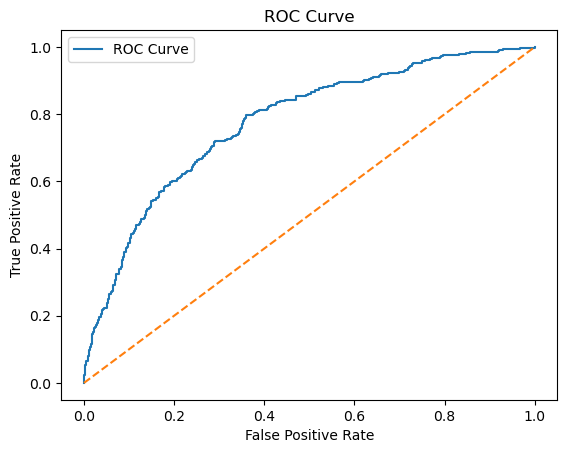

In [75]:
# ROC Curve ve AUC

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
y_prob = log_model.predict_proba(X_test_scaled)[:,1]  #predict_proba olasılık verir, predict direkt karar verir (0-1)
y_prob[0:10]  #müşterilerin churn etme olasılıkları

# Threshold = “churn demek için gereken minimum olasılık” 
roc_curve_data = roc_curve(y_test, y_prob) #bütün threshold değerlerini dener, üç liste olarak döndürür
fpr, tpr, thresholds = roc_curve_data #fpr: false positive rate, tpr: true positive rate

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [76]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, y_prob)     #test ile prob karşılaştırılır
print("AUC Score:", auc)


AUC Score: 0.7747778595236223


In [77]:
#Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=50,
    class_weight="balanced"  #?????
)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
confusion_matrix(y_test, y_pred_dt)
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1593
           1       0.43      0.75      0.54       407

    accuracy                           0.74      2000
   macro avg       0.67      0.75      0.68      2000
weighted avg       0.82      0.74      0.77      2000



In [78]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    class_weight="balanced",
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
confusion_matrix(y_test, y_pred_rf)
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.92      0.82      0.87      1593
           1       0.51      0.73      0.60       407

    accuracy                           0.80      2000
   macro avg       0.72      0.77      0.73      2000
weighted avg       0.84      0.80      0.81      2000



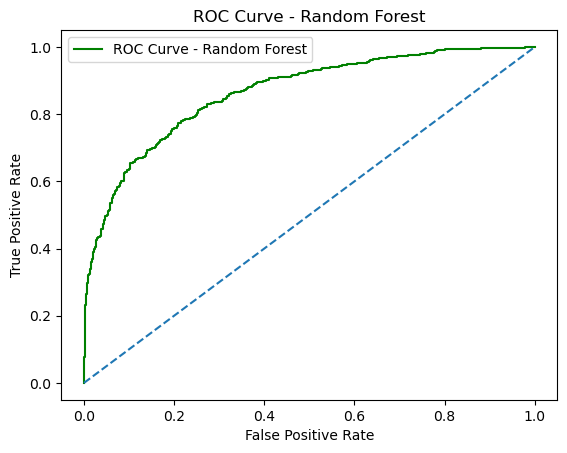

In [79]:
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
y_prob_rf[0:10]

roc_curve_data_rf = roc_curve(y_test, y_prob_rf)
fpr_rf, tpr_rf, thresholds_rf = roc_curve_data_rf

plt.plot(fpr_rf, tpr_rf, label="ROC Curve - Random Forest", color="green")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

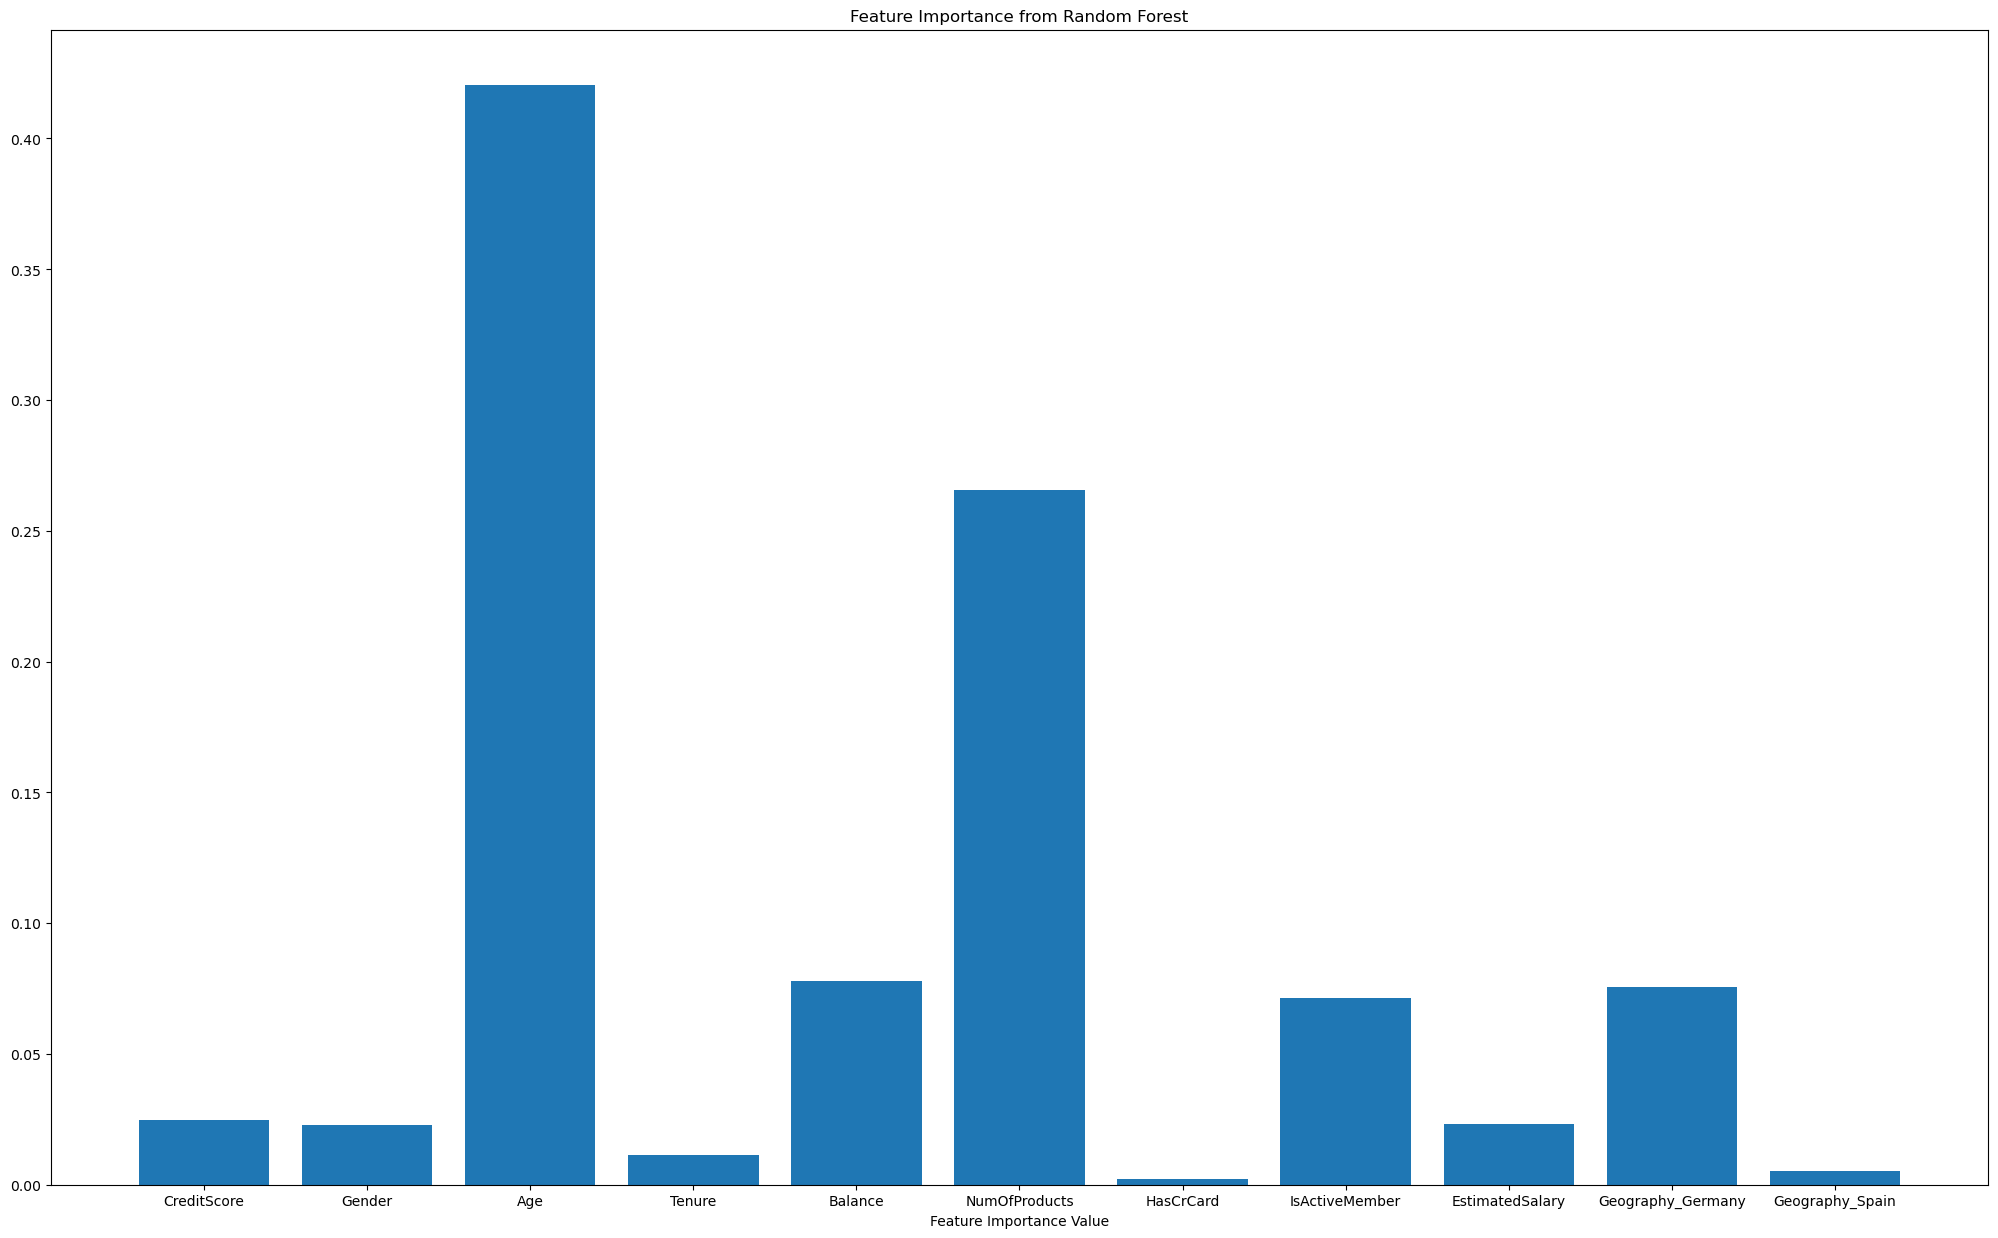

In [80]:
#Feature Importance

X.columns = rf_model.feature_names_in_
value = rf_model.feature_importances_
plt.figure(figsize=(25,15))
plt.bar(X.columns, value)
plt.xlabel("Feature Importance Value")
plt.title("Feature Importance from Random Forest")
plt.show()


In [81]:
#New Threshold Determination

y_pred_new_threashold = (y_prob_rf >= 0.3).astype(int)  #0.3 threshold değeri olarak belirledim
confusion_matrix(y_test, y_pred_new_threashold)
print(classification_report(y_test, y_pred_new_threashold))

              precision    recall  f1-score   support

           0       0.97      0.44      0.61      1593
           1       0.30      0.94      0.46       407

    accuracy                           0.54      2000
   macro avg       0.63      0.69      0.53      2000
weighted avg       0.83      0.54      0.58      2000



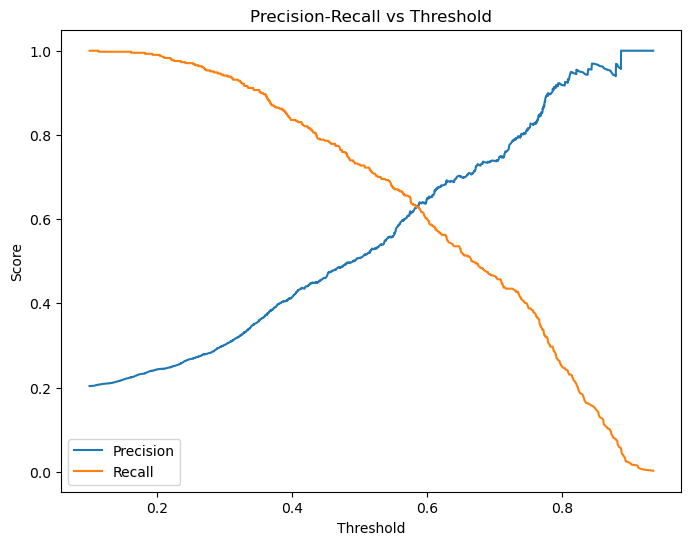

In [82]:
#Precision-Recall vs Threshold 

from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_rf)
plt.figure(figsize=(8,6))
plt.plot(thresholds, precision[:-1], label="Precision")  #???
plt.plot(thresholds, recall[:-1], label="Recall")      #???
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold")
plt.legend()
plt.show()

In [83]:
#AUC ile model kalitesi -> thresholddan bağımsız olarak model iyi mi değil mi

auc = roc_auc_score(y_test, y_prob_rf)     #test ile prob karşılaştırılır
print("AUC Score:", auc)

AUC Score: 0.8636001178374059


In [84]:
#Accuracy Scores

print("Train accuracy:", rf_model.score(X_train, y_train))
print("Test accuracy :", rf_model.score(X_test, y_test))


Train accuracy: 0.819625
Test accuracy : 0.8015


In [85]:
#Feature Importance Sorting

fi_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

fi_df.head(5)


,feature,importance
2,Age,0.420613
5,NumOfProducts,0.265573
4,Balance,0.077788
9,Geography_Germany,0.075633
7,IsActiveMember,0.071200


In [86]:
#Dummy Classifier

from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

y_dummy = dummy.predict(X_test)
print(classification_report(y_test, y_dummy))


              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1593
           1       0.00      0.00      0.00       407

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.63      0.80      0.71      2000



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [88]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier()
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.88      0.94      0.91      1593
           1       0.68      0.48      0.56       407

    accuracy                           0.85      2000
   macro avg       0.78      0.71      0.74      2000
weighted avg       0.84      0.85      0.84      2000



In [89]:
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]
roc_curve_data_xgb = roc_curve(y_test, y_prob_xgb)
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve_data_xgb

auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print("AUC Score XGBoost:", auc_xgb)

AUC Score XGBoost: 0.8328343752072566
